# AI-Powered Job Recommendation System for Candidates  
## Complete ML Model Implementation & Evaluation Notebook

**Project Goal:**  
Build and evaluate ML models on the provided preprocessed resumes & jobs datasets for a candidate-focused job recommendation system.

**Models Covered:**
- **Classification** → Predict `Recruiter Decision` (Hire / Reject)
- **Regression** → Predict `Salary Expectation ($)`
- **Clustering** → Group similar candidate profiles
- **Content-Based Recommendation** → Match any resume to the best jobs using skill similarity

**Evaluation Metrics Included:**
- Regression: MAE, RMSE, R²
- Classification: Accuracy, Precision, Recall, F1-score, Confusion Matrix
- Clustering: Silhouette Score

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load Datasets
resumes = pd.read_csv('datasets/preprocessed_resumes.csv')
jobs = pd.read_csv('datasets/preprocessed_jobs.csv')

print("Resumes shape:", resumes.shape)
print("Jobs shape:", jobs.shape)
print("\nResumes columns:", resumes.columns.tolist())
print("Jobs columns:", jobs.columns.tolist())

resumes.head()

FileNotFoundError: [Errno 2] No such file or directory: 'preprocessed_resumes.csv'

In [12]:
# Quick EDA
print("===> Resumes Dataset Info <===")
print(resumes.info())
print("\nRecruiter Decision Distribution:")
print(resumes['Recruiter Decision'].value_counts())

print("\n===> Jobs Dataset Info <===")
print(jobs.info())

===> Resumes Dataset Info <===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB
None

Recruiter Decision Distribution:
Recruiter Decision
Hire      812
Reject    188
Name: count, dtype: int64

===> Jobs Dataset Info 

In [13]:
# Encode 'Recruiter Decision' for classification
le_decision = LabelEncoder()
resumes['Decision_encoded'] = le_decision.fit_transform(resumes['Recruiter Decision'])

# Remove leaking feature for classification
numeric_features = ['Experience (Years)', 'Projects Count']   # Removed 'AI Score'

# Skills TF-IDF
tfidf = TfidfVectorizer(max_features=400, stop_words='english')
resumes['Skills'] = resumes['Skills'].fillna('').str.lower()
skills_tfidf = tfidf.fit_transform(resumes['Skills'])
skills_df = pd.DataFrame(skills_tfidf.toarray(), columns=[f"skill_{i}" for i in range(skills_tfidf.shape[1])])

# Final features for Classification (no leakage)
X_class = pd.concat([resumes[numeric_features], skills_df], axis=1)

# For Regression, we CAN keep AI Score if we want (as it's useful for salary)
X_reg = pd.concat([resumes[numeric_features + ['AI Score (0-100)']], skills_df], axis=1)

y_class = resumes['Decision_encoded']
y_reg = resumes['Salary Expectation ($)']

print("Feature Engineering - Done!")
print("X_class shape:", X_class.shape)

Feature Engineering - Done!
X_class shape: (1000, 17)


In [14]:
# Train-Test Split
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Classification split:", X_train_class.shape, X_test_class.shape)
print("Regression split:", X_train_reg.shape, X_test_reg.shape)

Classification split: (800, 17) (200, 17)
Regression split: (800, 18) (200, 18)


In [15]:
# MODEL 1: CLASSIFICATION - Predict Recruiter Decision (Hire/Reject)
clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
clf.fit(X_train_class, y_train_class)
y_pred_class = clf.predict(X_test_class)



===> CLASSIFICATION RESULTS <===
Accuracy : 0.95
Precision: 0.868421052631579
Recall   : 0.868421052631579
F1-Score : 0.868421052631579


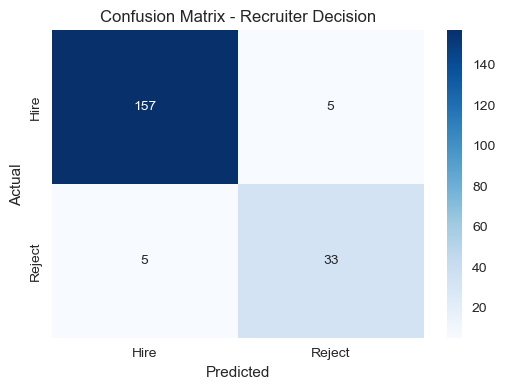

In [16]:
# Evaluation
print("===> CLASSIFICATION RESULTS <===")
print("Accuracy :", accuracy_score(y_test_class, y_pred_class))
print("Precision:", precision_score(y_test_class, y_pred_class))
print("Recall   :", recall_score(y_test_class, y_pred_class))
print("F1-Score :", f1_score(y_test_class, y_pred_class))

# Confusion Matrix
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_decision.classes_,
            yticklabels=le_decision.classes_)
plt.title('Confusion Matrix - Recruiter Decision')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [17]:
# MODEL 2: REGRESSION - Predict Salary Expectation
reg = RandomForestRegressor(n_estimators=200, random_state=42)
reg.fit(X_train_reg, y_train_reg)
y_pred_reg = reg.predict(X_test_reg)


===> REGRESSION RESULTS <===
MAE  : 22709.90
RMSE : 26968.00
R²   : -0.2199


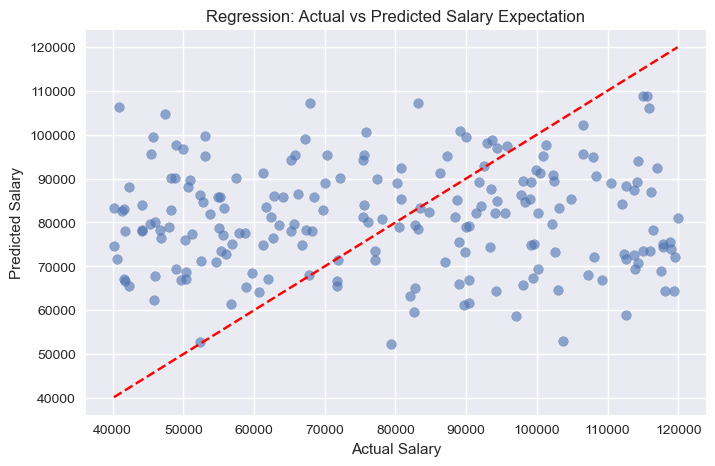

In [18]:
# Evaluation
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("===> REGRESSION RESULTS <===")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# Visualization
plt.figure(figsize=(8,5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Regression: Actual vs Predicted Salary Expectation')
plt.show()

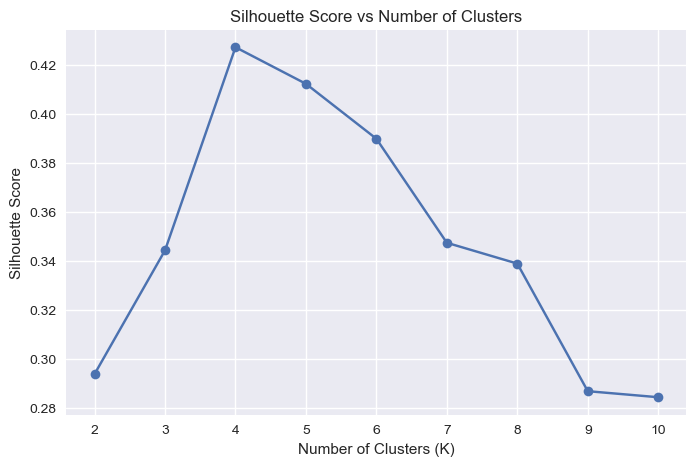

Best number of clusters: 4
Silhouette Score: 0.4274


,Resume_ID,Job Role,Cluster
0,1,AI Researcher,2
1,2,Data Scientist,1
2,3,Cybersecurity Analyst,0
3,4,AI Researcher,2
4,5,Software Engineer,3
5,6,Cybersecurity Analyst,0
6,7,Cybersecurity Analyst,0
7,8,AI Researcher,2
8,9,Cybersecurity Analyst,0
9,10,AI Researcher,2


In [20]:
# MODEL 3: CLUSTERING - Candidate Profiles
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_class)

# Find best K using Silhouette Score
sil_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

# Plot
plt.figure(figsize=(8,5))
plt.plot(k_range, sil_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Train final clustering model with best K
best_k = k_range[np.argmax(sil_scores)]
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

print(f"Best number of clusters: {best_k}")
print(f"Silhouette Score: {max(sil_scores):.4f}")

# Add cluster to resumes
resumes['Cluster'] = cluster_labels
resumes[['Resume_ID', 'Job Role', 'Cluster']].head(10)

In [ ]:
# RECOMMENDATION SYSTEM (Candidate-Focused)
# Build job-side TF-IDF using the same vocabulary learned from resume skills.
possible_job_skill_cols = [
    'Skills', 'skills', 'Required Skills', 'required_skills',
    'job_description', 'description'
]
job_skill_col = next((col for col in possible_job_skill_cols if col in jobs.columns), None)
if job_skill_col is None:
    raise ValueError(
        "No skills/description column found in jobs dataset. "
        f"Available columns: {jobs.columns.tolist()}"
    )

jobs[job_skill_col] = jobs[job_skill_col].fillna('').astype(str).str.lower()
jobs_tfidf = tfidf.transform(jobs[job_skill_col])


def recommend_jobs(resume_idx, top_n=10):
    """Recommend top jobs for a given resume using skill similarity."""
    if resume_idx < 0 or resume_idx >= len(resumes):
        raise IndexError(f"resume_idx must be between 0 and {len(resumes)-1}")

    top_n = max(1, min(top_n, len(jobs)))

    resume_vector = skills_tfidf[resume_idx]  # TF-IDF of selected resume
    similarity_scores = (jobs_tfidf @ resume_vector.T).toarray().flatten()

    top_indices = similarity_scores.argsort()[-top_n:][::-1]

    recommendations = jobs.iloc[top_indices].copy()
    recommendations['Match_Score'] = similarity_scores[top_indices] * 100

    display_cols = [c for c in ['job_id', 'job_title', 'category'] if c in recommendations.columns]
    if not display_cols:
        display_cols = recommendations.columns[:3].tolist()

    return recommendations[display_cols + ['Match_Score']]


# Example: Recommend jobs for resume index 25
print("=== Top 5 Job Recommendations for Resume index = 25 ===")
recs = recommend_jobs(25, top_n=5)
display(recs)

=== Top 5 Job Recommendations for Resume_ID = 25 ===


NameError: name 'jobs_tfidf' is not defined

In [47]:
# Save models & final summary
import joblib
joblib.dump(clf, 'model_classifier.pkl')
joblib.dump(reg, 'model_regressor.pkl')
joblib.dump(kmeans_final, 'model_clustering.pkl')
print(" All models saved successfully!")

 All models saved successfully!
